## 6.2 Data cleaning and preparation

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
#data = 'https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv'

In [5]:
#!wget $data

In [6]:
df = pd.read_csv('CreditScoring.csv')

In [7]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


### Data cleaning and preparation

In [8]:
df.columns = df.columns.str.lower()
df.head(2)

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658


In [9]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [10]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

In [11]:
status_values

{1: 'ok', 2: 'default', 0: 'unk'}

In [12]:
df.status = df.status.map(status_values)
df.head(2)

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658


In [13]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}
df.home = df.home.map(home_values)
 
marital_values = {
    1: 'single', 
    2: 'married', 
    3: 'widow', 
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}
df.marital = df.marital.map(marital_values)
 
records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}
df.records = df.records.map(records_values)
 
job_values = {
    1: 'fixed', 
    2: 'partime', 
    3: 'freelance', 
    4: 'others',
    0: 'unk'
}
df.job = df.job.map(job_values)
 
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [14]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [15]:
df.income.replace(to_replace=99999999, value=np.nan).max()

np.float64(959.0)

In [16]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan).max()

In [17]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,959.0,300000.0,30000.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,0.0,0.0,0.0,475.0,628.0
min,0.0,6.0,18.0,35.0,959.0,300000.0,30000.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,959.0,300000.0,30000.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,959.0,300000.0,30000.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,959.0,300000.0,30000.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [18]:
df = df[df.status != 'unk'].reset_index(drop=True)
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,959.0,300000.0,30000.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,959.0,300000.0,30000.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,959.0,300000.0,30000.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,959.0,300000.0,30000.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,959.0,300000.0,30000.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,959.0,300000.0,30000.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,959.0,300000.0,30000.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,959.0,300000.0,30000.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,959.0,300000.0,30000.0,550,550


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state = 11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state = 11)

In [21]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [22]:
y_train = (df_train.status == 'default').astype(int).values
y_val = (df_val.status == 'default').astype(int).values
y_test = (df_test.status == 'default').astype(int).values

In [23]:
del df_train['status']
del df_val['status']
del df_test['status']

In [24]:
df_val.shape

(891, 13)

In [25]:
df_train.shape

(2672, 13)

## 6.3 - Decision Trees

In [26]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client ['job'] == 'parttime':
            return 'default'
    else:
        if client['assets']>6000:
            return 'ok'
        else:
            return 'default'

In [27]:
df_train.iloc[0].to_dict()

{'seniority': 10,
 'home': 'owner',
 'time': 36,
 'age': 36,
 'marital': 'married',
 'records': 'no',
 'job': 'freelance',
 'expenses': 75,
 'income': 959.0,
 'assets': 300000.0,
 'debt': 30000.0,
 'amount': 1000,
 'price': 1400}

In [28]:
xi = df_train.iloc[0].to_dict()

In [29]:
assess_risk(xi)

'ok'

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [31]:
trains_dicts = df_train.fillna(0).to_dict(orient = 'records')

In [32]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(trains_dicts)

In [33]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [35]:
y_pred = dt.predict_proba(X_val)[:,1]

In [36]:
roc_auc_score(y_val, y_pred)

0.634139400837955

In [37]:
y_pred = dt.predict_proba(X_train)[:,1]
roc_auc_score(y_train, y_pred)

1.0

Estos valores implican un modelo sobreajustado

In [38]:
#Limito el modelo para que no se sobreajuste
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
y_pred = dt.predict_proba(X_val)[:,1]
auc= roc_auc_score(y_val, y_pred)
print ('val:', auc)

y_pred = dt.predict_proba(X_train)[:,1]
auc = roc_auc_score(y_train, y_pred)
print ('test:', auc)

val: 0.7128278559492383
test: 0.7717970114359753


In [40]:
from sklearn.tree import export_text
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- seniority <= 5.50
|   |   |   |--- class: 0
|   |   |--- seniority >  5.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- price <= 1049.00
|   |   |   |--- class: 1
|   |   |--- price >  1049.00
|   |   |   |--- class: 1
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- time <= 15.00
|   |   |   |--- class: 0
|   |   |--- time >  15.00
|   |   |   |--- class: 0



## 6.5 Decision trees parameter tuning

In [41]:
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]
 
for depth in depths: 
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
     
    # remember we need the column with negative scores
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
     
    print('%4s -> %.3f' % (depth, auc))

   1 -> 0.606
   2 -> 0.669
   3 -> 0.713
   4 -> 0.719
   5 -> 0.738
   6 -> 0.747
  10 -> 0.677
  15 -> 0.637
  20 -> 0.647
None -> 0.630


In [42]:
scores = []
 
for d in [4, 5, 6]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)
 
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
         
        scores.append((d, s, auc))
 
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,min_samples_leaf,auc
0,4,1,0.639534
1,4,2,0.652300
2,4,5,0.684735
3,4,10,0.717520
4,4,15,0.727692


In [43]:
df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
6,4,100,0.745698
24,6,100,0.745698
15,5,100,0.745698
16,5,200,0.742619
25,6,200,0.742619


In [44]:
# index - rows
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

auc              
max_depth             4      5      6
min_samples_leaf                     
1                 0.640  0.629  0.641
2                 0.652  0.654  0.660
5                 0.685  0.689  0.696
10                0.718  0.718  0.715
15                0.728  0.727  0.728
20                0.729  0.729  0.729
100               0.746  0.746  0.746
200               0.743  0.743  0.743
500               0.674  0.674  0.674

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

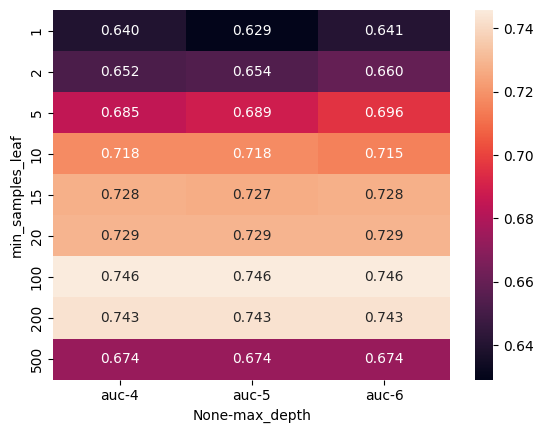

In [45]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [46]:
scores = []
 
for d in [4, 5, 6, 7, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)
 
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
         
        scores.append((d, s, auc))
 
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
 
df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
6,4.0,100,0.745698
51,15.0,100,0.745698
69,NaN,100,0.745698
60,20.0,100,0.745698
42,10.0,100,0.745698


In [47]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.631  0.625  0.631  0.634  0.633  0.636  0.629  0.633
2                 0.659  0.661  0.663  0.655  0.657  0.660  0.656  0.655
5                 0.691  0.690  0.695  0.686  0.693  0.695  0.689  0.689
10                0.715  0.715  0.717  0.717  0.715  0.717  0.718  0.715
15                0.726  0.730  0.730  0.730  0.728  0.728  0.728  0.729
20                0.729  0.729  0.729  0.730  0.729  0.729  0.729  0.729
100               0.746  0.746  0.746  0.746  0.746  0.746  0.746  0.746
200               0.743  0.743  0.743  0.743  0.743  0.743  0.743  0.743
500               0.674  0.674  0.674  0.674  0.674  0.674  0.674  0.674

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

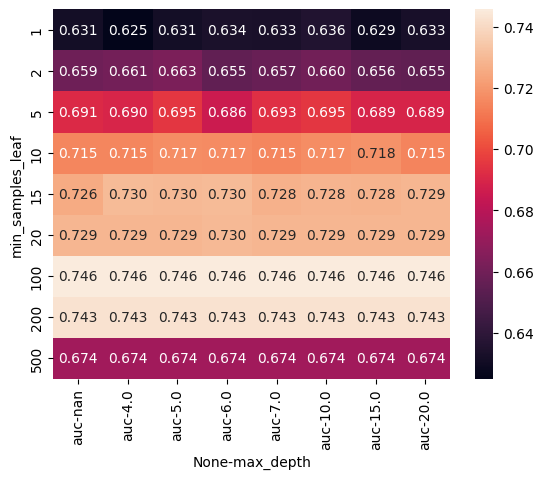

In [48]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [49]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 06-random-forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)
 
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)
# Output: 0.7744726453706618
 
rf.predict_proba(X_val[[0]])
# Output: array([[0.9, 0.1]])

array([[0.9, 0.1]])

In [52]:
scores = []
 
for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
 
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
     
    scores.append((n, auc))
 
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores

,n_estimators,auc
0,10,0.736798
1,20,0.759148
2,30,0.757262
3,40,0.763892
4,50,0.765706
5,60,0.770331
6,70,0.772102
7,80,0.772505
8,90,0.772838
9,100,0.772245


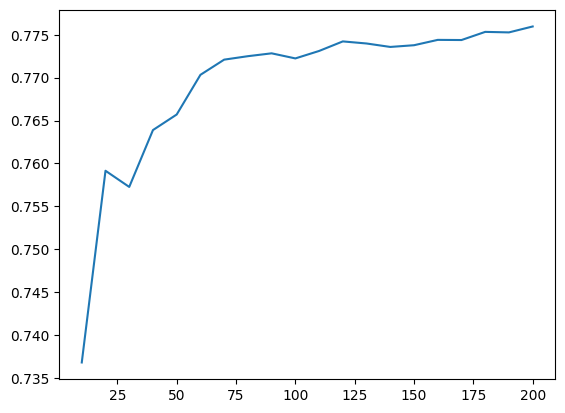

In [53]:
# x-axis - n_estimators
# y-axis - auc score
plt.plot(df_scores.n_estimators, df_scores.auc)

In [54]:
scores = []
 
for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        rf.fit(X_train, y_train)
 
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
 
        scores.append((d, n, auc))
 
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.759663
1,5,20,0.768721
2,5,30,0.771748
3,5,40,0.774451
4,5,50,0.774291


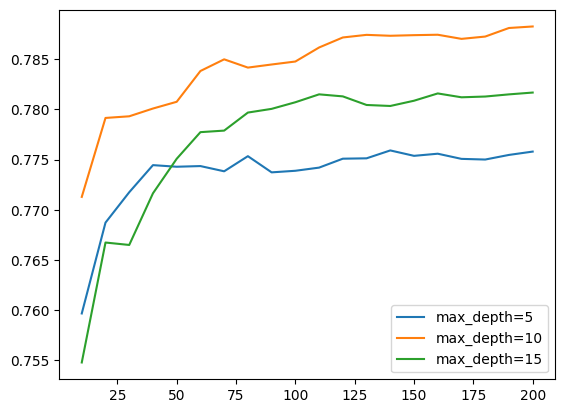

In [55]:
# Let's plot it
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
     
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)
 
plt.legend()

In [56]:
# Let's select 10 as the best value
max_depth = 10

In [57]:
scores = []
 
for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)
 
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
 
        scores.append((s, n, auc))
 
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

In [58]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
list(zip(min_samples_leaf_values, colors))
 
# Output: [(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]


[(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]

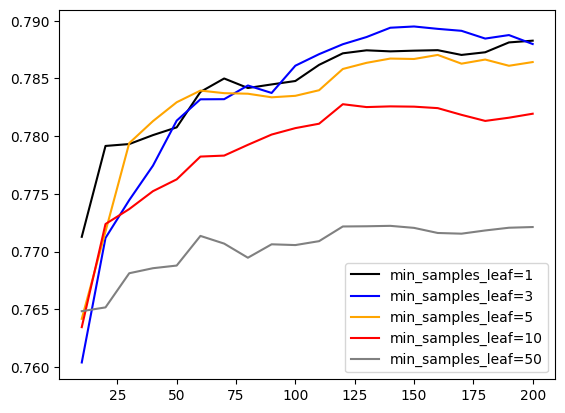

In [59]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
 
for s, col in zip(min_samples_leaf_values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
     
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)
 
plt.legend()

In [60]:
# Let's select 3 as the best value
min_samples_leaf = 3

In [61]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1,
                            n_jobs=-1)
rf.fit(X_train, y_train)
 
# Output: 
# RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_jobs=-1,
#                       random_state=1)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 6.7 Gradient boosting and XGBoost

In [62]:
#!pip install xgboost
 
#import xgboost as xgb

In [70]:
features = dv.get_feature_names_out()

In [72]:
features

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [73]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(features))

In [76]:
dval = xgb.DMatrix(X_val, label=y_val, feature_names=list(features))

In [74]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
    'nthread': 8,
     
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, dtrain, num_boost_round= 10)

In [77]:
y_pred = model.predict(dval)

In [78]:
roc_auc_score(y_val, y_pred)

0.7733495192656996

In [79]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [80]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  evals=watchlist)

[0]	train-logloss:0.51028	val-logloss:0.55388
[1]	train-logloss:0.46549	val-logloss:0.53270
[2]	train-logloss:0.43464	val-logloss:0.52119
[3]	train-logloss:0.41133	val-logloss:0.51076
[4]	train-logloss:0.39181	val-logloss:0.50645
[5]	train-logloss:0.37850	val-logloss:0.50414
[6]	train-logloss:0.36362	val-logloss:0.50556
[7]	train-logloss:0.35428	val-logloss:0.50659
[8]	train-logloss:0.34314	val-logloss:0.51122
[9]	train-logloss:0.33426	val-logloss:0.51198
[10]	train-logloss:0.32622	val-logloss:0.51203
[11]	train-logloss:0.31707	val-logloss:0.51481
[12]	train-logloss:0.30908	val-logloss:0.51548
[13]	train-logloss:0.30234	val-logloss:0.51674
[14]	train-logloss:0.29966	val-logloss:0.51781
[15]	train-logloss:0.29515	val-logloss:0.52101
[16]	train-logloss:0.29159	val-logloss:0.51994
[17]	train-logloss:0.28784	val-logloss:0.52087
[18]	train-logloss:0.28049	val-logloss:0.52581
[19]	train-logloss:0.27790	val-logloss:0.52558
[20]	train-logloss:0.27565	val-logloss:0.52498
[21]	train-logloss:0.27

In [81]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  evals=watchlist)

[0]	train-auc:0.83894	val-auc:0.74952
[1]	train-auc:0.86089	val-auc:0.75998
[2]	train-auc:0.87492	val-auc:0.76164
[3]	train-auc:0.88417	val-auc:0.77005
[4]	train-auc:0.89560	val-auc:0.77440
[5]	train-auc:0.89952	val-auc:0.77561
[6]	train-auc:0.90866	val-auc:0.77540
[7]	train-auc:0.91387	val-auc:0.77582
[8]	train-auc:0.91905	val-auc:0.77252
[9]	train-auc:0.92427	val-auc:0.77335
[10]	train-auc:0.92891	val-auc:0.77452
[11]	train-auc:0.93389	val-auc:0.77319
[12]	train-auc:0.93808	val-auc:0.77362
[13]	train-auc:0.94193	val-auc:0.77341
[14]	train-auc:0.94248	val-auc:0.77298
[15]	train-auc:0.94455	val-auc:0.77274
[16]	train-auc:0.94597	val-auc:0.77414
[17]	train-auc:0.94803	val-auc:0.77454
[18]	train-auc:0.95168	val-auc:0.77150
[19]	train-auc:0.95298	val-auc:0.77211
[20]	train-auc:0.95398	val-auc:0.77355
[21]	train-auc:0.95695	val-auc:0.77402
[22]	train-auc:0.95983	val-auc:0.77247
[23]	train-auc:0.96304	val-auc:0.77277
[24]	train-auc:0.96382	val-auc:0.77308
[25]	train-auc:0.96589	val-auc:0.77

In [82]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

[0]	train-auc:0.83894	val-auc:0.74952
[5]	train-auc:0.89952	val-auc:0.77561
[10]	train-auc:0.92891	val-auc:0.77452
[15]	train-auc:0.94455	val-auc:0.77274
[20]	train-auc:0.95398	val-auc:0.77355
[25]	train-auc:0.96589	val-auc:0.77188
[30]	train-auc:0.97194	val-auc:0.76901
[35]	train-auc:0.97596	val-auc:0.76978
[40]	train-auc:0.98190	val-auc:0.76897
[45]	train-auc:0.98712	val-auc:0.76719
[50]	train-auc:0.99037	val-auc:0.76400
[55]	train-auc:0.99294	val-auc:0.76330
[60]	train-auc:0.99380	val-auc:0.76290
[65]	train-auc:0.99568	val-auc:0.76200
[70]	train-auc:0.99669	val-auc:0.76127
[75]	train-auc:0.99747	val-auc:0.75874
[80]	train-auc:0.99835	val-auc:0.75603
[85]	train-auc:0.99872	val-auc:0.75471
[90]	train-auc:0.99903	val-auc:0.75318
[95]	train-auc:0.99930	val-auc:0.75409
[100]	train-auc:0.99953	val-auc:0.75649
[105]	train-auc:0.99963	val-auc:0.75726
[110]	train-auc:0.99972	val-auc:0.75741
[115]	train-auc:0.99980	val-auc:0.75591
[120]	train-auc:0.99990	val-auc:0.75551
[125]	train-auc:0.9999

In [83]:
%%capture output
 
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)


In [84]:
s = output.stdout
 
print(s)

[0]	train-auc:0.83894	val-auc:0.74952
[5]	train-auc:0.89952	val-auc:0.77561
[10]	train-auc:0.92891	val-auc:0.77452
[15]	train-auc:0.94455	val-auc:0.77274
[20]	train-auc:0.95398	val-auc:0.77355
[25]	train-auc:0.96589	val-auc:0.77188
[30]	train-auc:0.97194	val-auc:0.76901
[35]	train-auc:0.97596	val-auc:0.76978
[40]	train-auc:0.98190	val-auc:0.76897
[45]	train-auc:0.98712	val-auc:0.76719
[50]	train-auc:0.99037	val-auc:0.76400
[55]	train-auc:0.99294	val-auc:0.76330
[60]	train-auc:0.99380	val-auc:0.76290
[65]	train-auc:0.99568	val-auc:0.76200
[70]	train-auc:0.99669	val-auc:0.76127
[75]	train-auc:0.99747	val-auc:0.75874
[80]	train-auc:0.99835	val-auc:0.75603
[85]	train-auc:0.99872	val-auc:0.75471
[90]	train-auc:0.99903	val-auc:0.75318
[95]	train-auc:0.99930	val-auc:0.75409
[100]	train-auc:0.99953	val-auc:0.75649
[105]	train-auc:0.99963	val-auc:0.75726
[110]	train-auc:0.99972	val-auc:0.75741
[115]	train-auc:0.99980	val-auc:0.75591
[120]	train-auc:0.99990	val-auc:0.75551
[125]	train-auc:0.9999

In [85]:
s.split('\n')

['[0]\ttrain-auc:0.83894\tval-auc:0.74952',
 '[5]\ttrain-auc:0.89952\tval-auc:0.77561',
 '[10]\ttrain-auc:0.92891\tval-auc:0.77452',
 '[15]\ttrain-auc:0.94455\tval-auc:0.77274',
 '[20]\ttrain-auc:0.95398\tval-auc:0.77355',
 '[25]\ttrain-auc:0.96589\tval-auc:0.77188',
 '[30]\ttrain-auc:0.97194\tval-auc:0.76901',
 '[35]\ttrain-auc:0.97596\tval-auc:0.76978',
 '[40]\ttrain-auc:0.98190\tval-auc:0.76897',
 '[45]\ttrain-auc:0.98712\tval-auc:0.76719',
 '[50]\ttrain-auc:0.99037\tval-auc:0.76400',
 '[55]\ttrain-auc:0.99294\tval-auc:0.76330',
 '[60]\ttrain-auc:0.99380\tval-auc:0.76290',
 '[65]\ttrain-auc:0.99568\tval-auc:0.76200',
 '[70]\ttrain-auc:0.99669\tval-auc:0.76127',
 '[75]\ttrain-auc:0.99747\tval-auc:0.75874',
 '[80]\ttrain-auc:0.99835\tval-auc:0.75603',
 '[85]\ttrain-auc:0.99872\tval-auc:0.75471',
 '[90]\ttrain-auc:0.99903\tval-auc:0.75318',
 '[95]\ttrain-auc:0.99930\tval-auc:0.75409',
 '[100]\ttrain-auc:0.99953\tval-auc:0.75649',
 '[105]\ttrain-auc:0.99963\tval-auc:0.75726',
 '[110]\tt

In [86]:
line = s.split('\n')[0]
line
# Output: '[0]\ttrain-auc:0.86730\tval-auc:0.77938'
 
line.split('\t')
# Output: ['[0]', 'train-auc:0.86730', 'val-auc:0.77938']
 
num_iter, train_auc, val_auc = line.split('\t')
num_iter, train_auc, val_auc
# Output: ('[0]', 'train-auc:0.86730', 'val-auc:0.77938')
 
int(num_iter.strip('[]'))
# Output: 0
float(train_auc.split(':')[1])
# Output: 0.8673
float(val_auc.split(':')[1])
# Output: 0.77938

0.74952

In [87]:
def parse_xgb_output(output):
    results = []
 
    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')
 
        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])
 
        results.append((it, train, val))
     
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [88]:
df_score = parse_xgb_output(output)
df_score

,num_iter,train_auc,val_auc
0,0,0.83894,0.74952
1,5,0.89952,0.77561
2,10,0.92891,0.77452
3,15,0.94455,0.77274
4,20,0.95398,0.77355
5,25,0.96589,0.77188
6,30,0.97194,0.76901
7,35,0.97596,0.76978
8,40,0.98190,0.76897
9,45,0.98712,0.76719


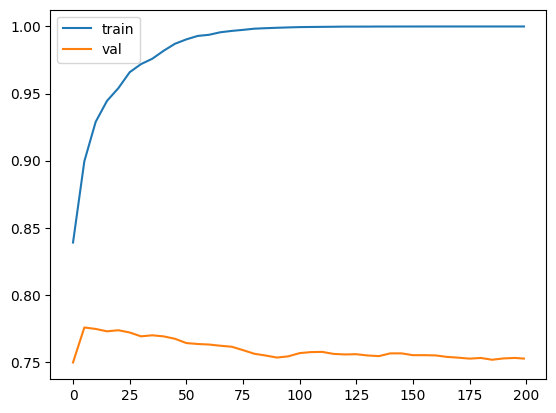

In [89]:
# x-axis - number of iterations
# y-axis - auc
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

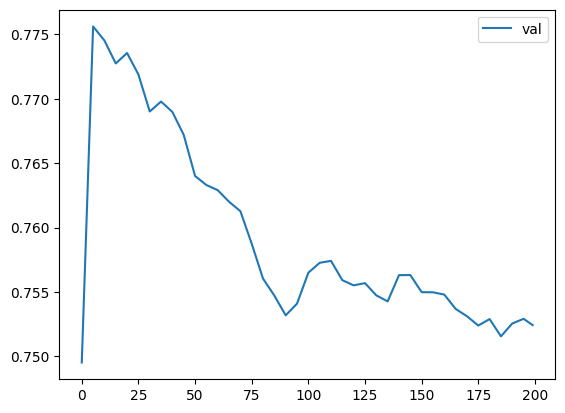

In [90]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()